# Anomaly Detection Methods in Python

This notebook provides a comprehensive overview of various anomaly detection methods, complete with explanations and code examples. It covers traditional statistical methods, clustering-based approaches, machine learning techniques, deep learning methods, and time series anomaly detection.

## Introduction

Anomaly detection is the process of identifying rare items, events, or observations that differ significantly from the majority of the data. Such methods are critical in fields like fraud detection, network security, and system monitoring. In the following sections, multiple approaches are demonstrated with code examples so you can apply these methods to your own datasets.

## 1. Statistical Anomaly Detection using Z-Score

The Z-score method assumes that the data follows a normal distribution. Data points that are more than a set number of standard deviations (commonly 3) away from the mean are flagged as anomalies.

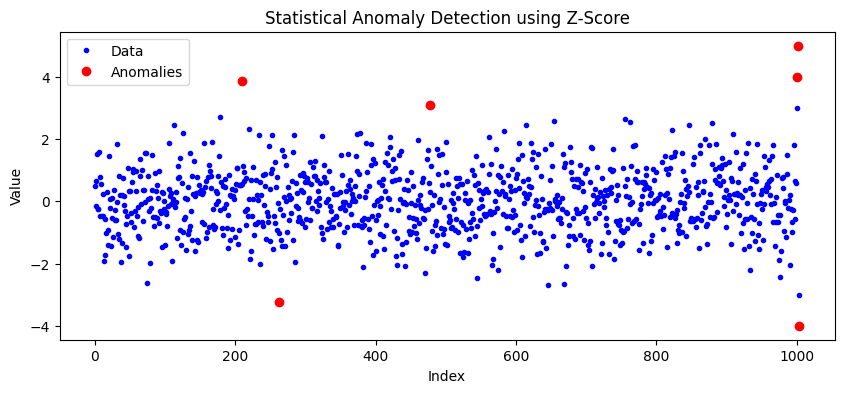

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats

# Generate synthetic data from a normal distribution
np.random.seed(42)
data = np.random.normal(0, 1, 1000)

# Introduce some anomalies
data_with_anomalies = np.concatenate([data, np.array([3, 4, 5, -3, -4])])

# Compute Z-scores
z_scores = stats.zscore(data_with_anomalies)
threshold = 3
anomaly_indices = np.where(np.abs(z_scores) > threshold)[0]

# Plot the results
plt.figure(figsize=(10, 4))
plt.plot(data_with_anomalies, 'b.', label='Data')
plt.plot(anomaly_indices, data_with_anomalies[anomaly_indices], 'ro', label='Anomalies')
plt.title('Statistical Anomaly Detection using Z-Score')
plt.xlabel('Index')
plt.ylabel('Value')
plt.legend()
plt.show()

## 2. Clustering-based Anomaly Detection using DBSCAN

DBSCAN (Density-Based Spatial Clustering of Applications with Noise) groups together points that are closely packed and marks points that do not belong to any cluster (labeled as `-1`) as anomalies.

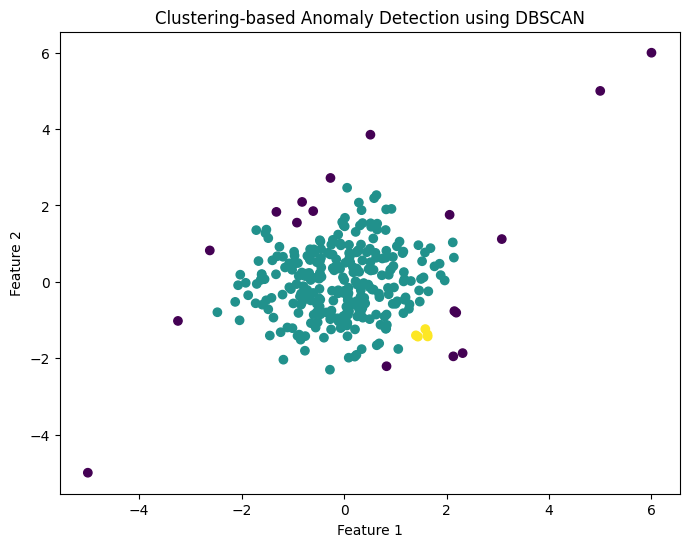

In [2]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.cluster import DBSCAN

# Create 2D synthetic data
np.random.seed(42)
X = np.random.randn(300, 2)

# Add some anomalies
anomalies = np.array([[5, 5], [6, 6], [-5, -5]])
X = np.vstack([X, anomalies])

# Apply DBSCAN
dbscan = DBSCAN(eps=0.5, min_samples=5)
labels = dbscan.fit_predict(X)

# Plot the clusters and anomalies
plt.figure(figsize=(8, 6))
plt.scatter(X[:, 0], X[:, 1], c=labels, cmap='viridis', marker='o')
plt.title('Clustering-based Anomaly Detection using DBSCAN')
plt.xlabel('Feature 1')
plt.ylabel('Feature 2')
plt.show()

## 3. Anomaly Detection using Isolation Forest

Isolation Forest is an ensemble method that isolates anomalies by randomly selecting features and split values. Anomalies are isolated faster, resulting in shorter average path lengths in the trees.

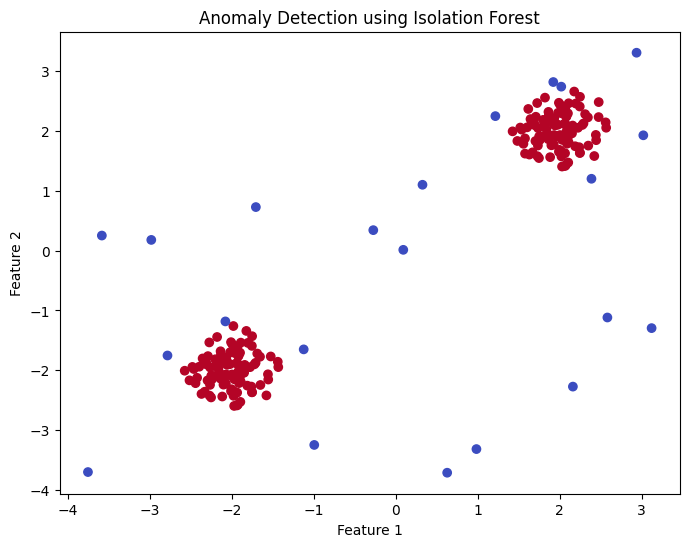

In [3]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.ensemble import IsolationForest

np.random.seed(42)
# Generate synthetic data
X_inliers = 0.3 * np.random.randn(100, 2)
X_inliers = np.r_[X_inliers + 2, X_inliers - 2]
X_outliers = np.random.uniform(low=-4, high=4, size=(20, 2))
X = np.r_[X_inliers, X_outliers]

# Fit the Isolation Forest model
clf = IsolationForest(contamination=0.1, random_state=42)
y_pred = clf.fit_predict(X)

# Plot the results
plt.figure(figsize=(8, 6))
plt.scatter(X[:, 0], X[:, 1], c=y_pred, cmap='coolwarm', marker='o')
plt.title('Anomaly Detection using Isolation Forest')
plt.xlabel('Feature 1')
plt.ylabel('Feature 2')
plt.show()

## 4. Anomaly Detection using Local Outlier Factor (LOF)

Local Outlier Factor (LOF) measures the local density deviation of a data point with respect to its neighbors. Points that exhibit significantly lower density than their neighbors are flagged as anomalies.

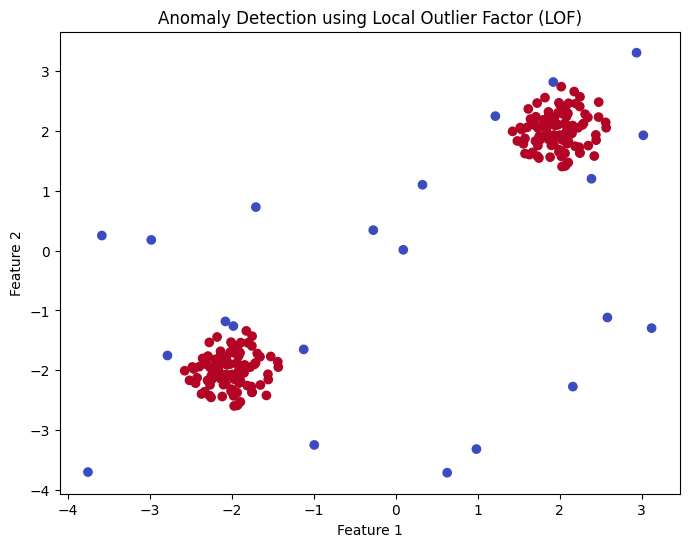

In [4]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.neighbors import LocalOutlierFactor

np.random.seed(42)
# Generate synthetic data
X_inliers = 0.3 * np.random.randn(100, 2)
X_inliers = np.r_[X_inliers + 2, X_inliers - 2]
X_outliers = np.random.uniform(low=-4, high=4, size=(20, 2))
X = np.r_[X_inliers, X_outliers]

# Apply LOF
lof = LocalOutlierFactor(n_neighbors=20, contamination=0.1)
y_pred = lof.fit_predict(X)

# Plot the results
plt.figure(figsize=(8, 6))
plt.scatter(X[:, 0], X[:, 1], c=y_pred, cmap='coolwarm', marker='o')
plt.title('Anomaly Detection using Local Outlier Factor (LOF)')
plt.xlabel('Feature 1')
plt.ylabel('Feature 2')
plt.show()

## 5. Anomaly Detection using One-Class SVM

One-Class SVM is used for novelty detection. It learns a decision function that encompasses the region where the training data lies. Points falling outside of this region are flagged as anomalies.

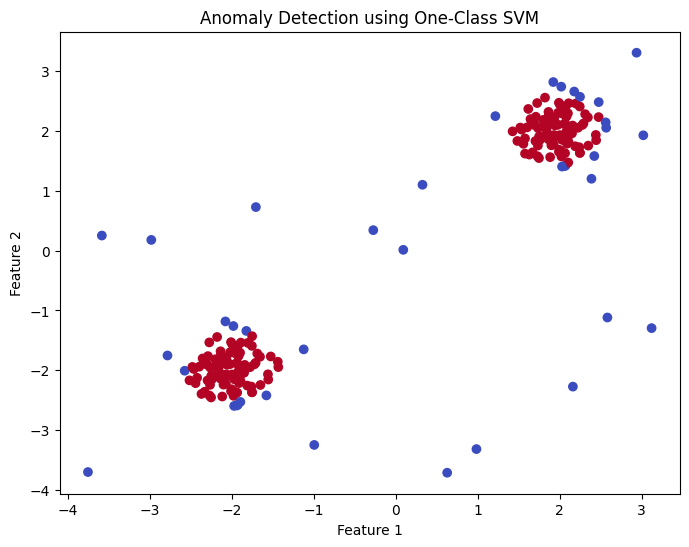

In [5]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.svm import OneClassSVM

np.random.seed(42)
# Generate synthetic data
X_inliers = 0.3 * np.random.randn(100, 2)
X_inliers = np.r_[X_inliers + 2, X_inliers - 2]
X_outliers = np.random.uniform(low=-4, high=4, size=(20, 2))
X_train = X_inliers
X_test = np.r_[X_train, X_outliers]

# Fit the One-Class SVM model
clf = OneClassSVM(nu=0.1, kernel='rbf', gamma=0.1)
clf.fit(X_train)
y_pred = clf.predict(X_test)

# Plot the results
plt.figure(figsize=(8, 6))
plt.scatter(X_test[:, 0], X_test[:, 1], c=y_pred, cmap='coolwarm', marker='o')
plt.title('Anomaly Detection using One-Class SVM')
plt.xlabel('Feature 1')
plt.ylabel('Feature 2')
plt.show()

## 6. PCA-Based Anomaly Detection

Principal Component Analysis (PCA) can be used for anomaly detection by reducing the dimensionality of the data and then reconstructing it using a limited number of principal components. Points with high reconstruction error (i.e. the difference between the original data and its reconstruction) are flagged as anomalies.

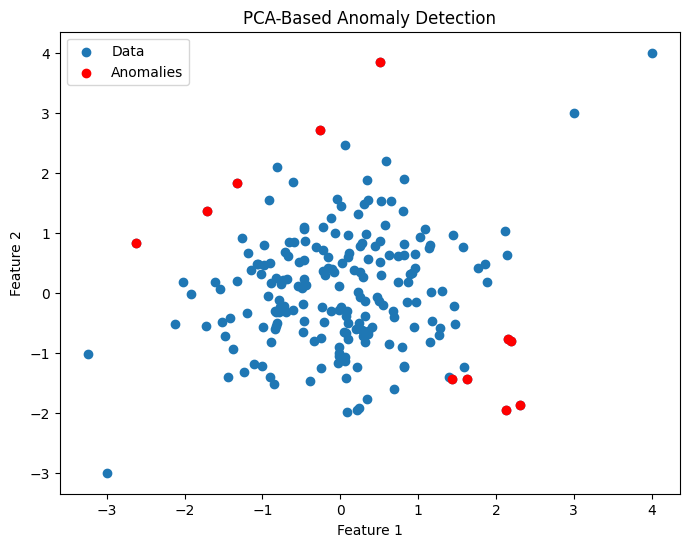

In [6]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA

# Generate synthetic 2D data
np.random.seed(42)
X = np.random.randn(200, 2)

# Introduce some anomalies
anomalies = np.array([[3, 3], [4, 4], [-3, -3]])
X_with_anomalies = np.vstack([X, anomalies])

# Apply PCA
pca = PCA(n_components=1)
X_projected = pca.fit_transform(X_with_anomalies)
X_reconstructed = pca.inverse_transform(X_projected)

# Compute reconstruction error
reconstruction_error = np.mean((X_with_anomalies - X_reconstructed) ** 2, axis=1)
threshold = np.percentile(reconstruction_error, 95)
anomaly_indices = np.where(reconstruction_error > threshold)[0]

# Plot the results
plt.figure(figsize=(8, 6))
plt.scatter(X_with_anomalies[:, 0], X_with_anomalies[:, 1], label='Data')
plt.scatter(X_with_anomalies[anomaly_indices, 0], X_with_anomalies[anomaly_indices, 1], color='red', label='Anomalies')
plt.title('PCA-Based Anomaly Detection')
plt.xlabel('Feature 1')
plt.ylabel('Feature 2')
plt.legend()
plt.show()

## 7. k-Nearest Neighbors (kNN) Based Anomaly Detection

In kNN-based anomaly detection, the average distance of each data point to its k-nearest neighbors is calculated. Points with a high average distance are considered anomalies.

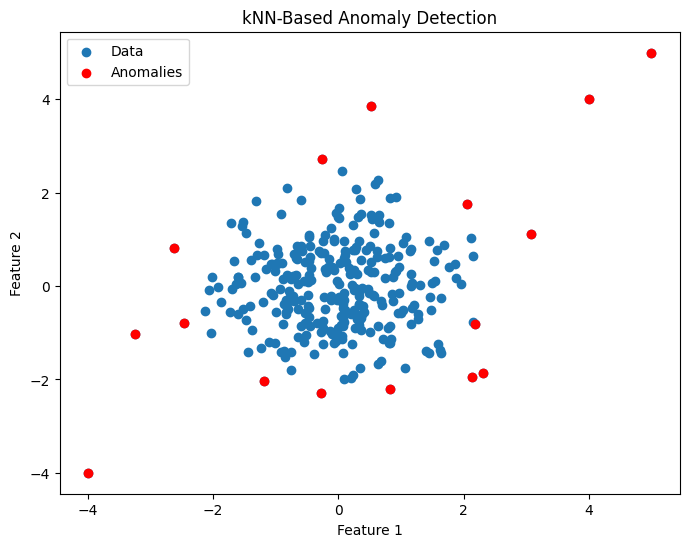

In [7]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.neighbors import NearestNeighbors

np.random.seed(42)
# Generate synthetic data
X = np.random.randn(300, 2)

# Add anomalies
anomalies = np.array([[4, 4], [5, 5], [-4, -4]])
X = np.vstack([X, anomalies])

# Compute distances to the 5 nearest neighbors
nbrs = NearestNeighbors(n_neighbors=5)
nbrs.fit(X)
distances, indices = nbrs.kneighbors(X)

# Use the average distance as an anomaly score
avg_distances = distances.mean(axis=1)
threshold = np.percentile(avg_distances, 95)
anomaly_indices = np.where(avg_distances > threshold)[0]

# Plot the results
plt.figure(figsize=(8, 6))
plt.scatter(X[:, 0], X[:, 1], label='Data')
plt.scatter(X[anomaly_indices, 0], X[anomaly_indices, 1], color='red', label='Anomalies')
plt.title('kNN-Based Anomaly Detection')
plt.xlabel('Feature 1')
plt.ylabel('Feature 2')
plt.legend()
plt.show()

## 8. Robust Covariance Estimation (Elliptic Envelope)

Robust covariance estimation fits an ellipse to the central data points by estimating a robust covariance matrix. Points outside the ellipse are considered anomalies. This method works well when the data is approximately Gaussian.

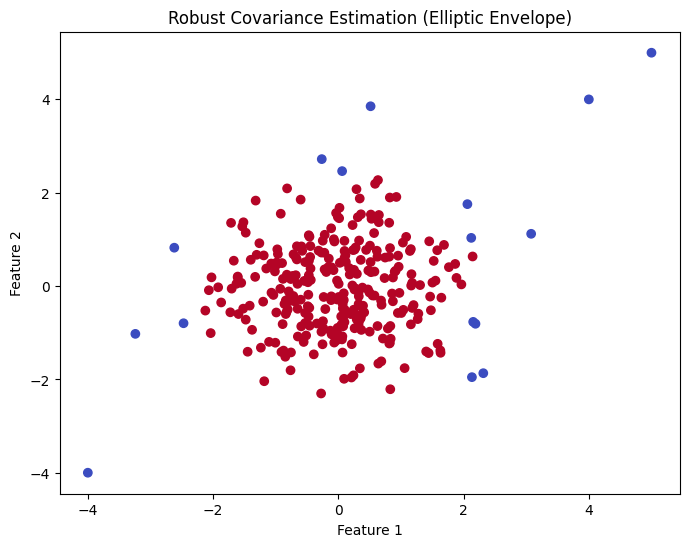

In [8]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.covariance import EllipticEnvelope

np.random.seed(42)
# Generate synthetic data
X = np.random.randn(300, 2)

# Add anomalies
anomalies = np.array([[4, 4], [5, 5], [-4, -4]])
X = np.vstack([X, anomalies])

# Fit the Elliptic Envelope model
ee = EllipticEnvelope(contamination=0.05)
y_pred = ee.fit_predict(X)

# Plot the results
plt.figure(figsize=(8, 6))
plt.scatter(X[:, 0], X[:, 1], c=y_pred, cmap='coolwarm', marker='o')
plt.title('Robust Covariance Estimation (Elliptic Envelope)')
plt.xlabel('Feature 1')
plt.ylabel('Feature 2')
plt.show()

## 9. Deep Learning Methods (Autoencoder) using PyTorch

Autoencoders are neural networks designed to learn a compressed representation of data. When trained on normal data, they can reconstruct the input well; however, anomalies usually yield a high reconstruction error. This example uses PyTorch to build, train, and evaluate a simple autoencoder with dropout regularization and robust thresholding.

Epoch 1/30  Loss: 1.011182
Epoch 2/30  Loss: 1.002628
Epoch 3/30  Loss: 0.994548
Epoch 4/30  Loss: 0.969108
Epoch 5/30  Loss: 0.949595
Epoch 6/30  Loss: 0.934950
Epoch 7/30  Loss: 0.923153
Epoch 8/30  Loss: 0.908747
Epoch 9/30  Loss: 0.897543
Epoch 10/30  Loss: 0.890158
Epoch 11/30  Loss: 0.883996
Epoch 12/30  Loss: 0.883497
Epoch 13/30  Loss: 0.873232
Epoch 14/30  Loss: 0.877002
Epoch 15/30  Loss: 0.870777
Epoch 16/30  Loss: 0.868355
Epoch 17/30  Loss: 0.863963
Epoch 18/30  Loss: 0.867700
Epoch 19/30  Loss: 0.862269
Epoch 20/30  Loss: 0.864676
Epoch 21/30  Loss: 0.860367
Epoch 22/30  Loss: 0.857155
Epoch 23/30  Loss: 0.864906
Epoch 24/30  Loss: 0.855298
Epoch 25/30  Loss: 0.848250
Epoch 26/30  Loss: 0.853487
Epoch 27/30  Loss: 0.850984
Epoch 28/30  Loss: 0.847807
Epoch 29/30  Loss: 0.843465
Epoch 30/30  Loss: 0.849710
Median error: 0.7877443
MAD: 0.18904531
Threshold: 1.9220161
Detected anomalies: 51


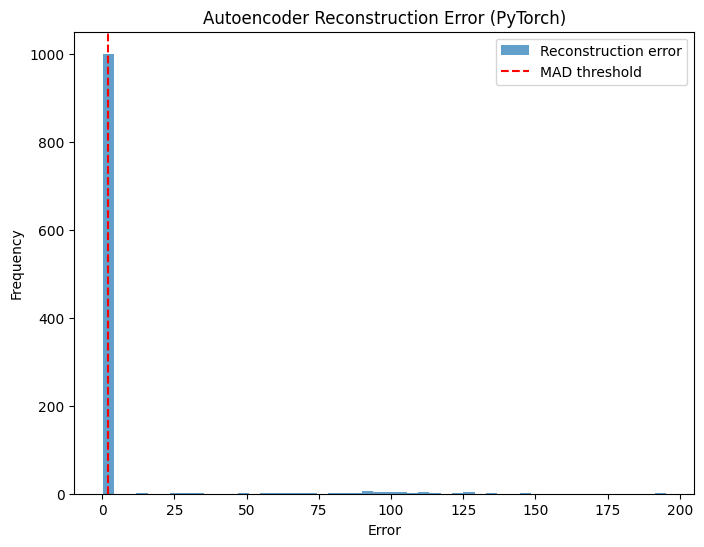

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
import torch.optim as optim

# -----------------------------
# Set seeds for reproducibility
# -----------------------------
np.random.seed(42)
torch.manual_seed(42)

# -----------------------------
# Synthetic dataset
# -----------------------------
X = np.random.normal(0, 1, (1000, 20))
n_anomalies = 50
anomalies = np.random.normal(0, 10, (n_anomalies, 20))

X_with_anomalies = np.vstack([X, anomalies])

X_train = torch.tensor(X, dtype=torch.float32)
X_all = torch.tensor(X_with_anomalies, dtype=torch.float32)

input_dim = X_train.shape[1]

# -----------------------------
# Define the Autoencoder model
# -----------------------------
class Autoencoder(nn.Module):

    def __init__(self, input_dim):
        super().__init__()

        self.encoder = nn.Sequential(
            nn.Linear(input_dim, 32),
            nn.ReLU(),
            nn.Dropout(0.2),

            nn.Linear(32, 16),
            nn.ReLU(),
            nn.Dropout(0.2),

            nn.Linear(16, 8),
            nn.ReLU()
        )

        self.decoder = nn.Sequential(
            nn.Linear(8, 16),
            nn.ReLU(),
            nn.Dropout(0.2),

            nn.Linear(16, 32),
            nn.ReLU(),

            nn.Linear(32, input_dim)
        )

    def forward(self, x):

        z = self.encoder(x)
        x_hat = self.decoder(z)

        return x_hat


model = Autoencoder(input_dim)

# -----------------------------
# Loss and optimizer
# -----------------------------
criterion = nn.MSELoss()
optimizer = optim.Adam(model.parameters(), lr=1e-3)

# -----------------------------
# Training parameters
# -----------------------------
num_epochs = 30
batch_size = 32

dataset = torch.utils.data.TensorDataset(X_train)

dataloader = torch.utils.data.DataLoader(
    dataset,
    batch_size=batch_size,
    shuffle=True
)

# -----------------------------
# Training loop
# -----------------------------
model.train()

for epoch in range(num_epochs):

    epoch_loss = 0

    for batch in dataloader:

        batch_data = batch[0]

        optimizer.zero_grad()

        outputs = model(batch_data)

        loss = criterion(outputs, batch_data)

        loss.backward()

        optimizer.step()

        epoch_loss += loss.item()

    print(f"Epoch {epoch+1}/{num_epochs}  Loss: {epoch_loss/len(dataloader):.6f}")


# -----------------------------
# Evaluation
# -----------------------------
model.eval()

with torch.no_grad():

    X_reconstructed = model(X_all)

reconstruction_error = torch.mean(
    (X_all - X_reconstructed) ** 2,
    dim=1
).numpy()

# -----------------------------
# Robust threshold (MAD)
# -----------------------------
median_error = np.median(reconstruction_error)

mad = np.median(np.abs(reconstruction_error - median_error))

k = 6

threshold = median_error + k * mad

anomaly_indices = np.where(reconstruction_error > threshold)[0]

print("Median error:", median_error)
print("MAD:", mad)
print("Threshold:", threshold)
print("Detected anomalies:", len(anomaly_indices))


# -----------------------------
# Histogram
# -----------------------------
plt.figure(figsize=(8,6))

plt.hist(
    reconstruction_error,
    bins=50,
    alpha=0.7,
    label="Reconstruction error"
)

plt.axvline(
    threshold,
    color="red",
    linestyle="--",
    label="MAD threshold"
)

plt.xlabel("Error")
plt.ylabel("Frequency")
plt.title("Autoencoder Reconstruction Error (PyTorch)")
plt.legend()

plt.show()

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 20)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 32)             │           672 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 16)             │           528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 16)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 8)              │           136 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 16)             │           144 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 16)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 32)             │           544 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 20)             │           660 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,684 (10.48 KB)

 Trainable params: 2,684 (10.48 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/30
29/29 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 1.0086 - val_loss: 0.9876
Epoch 2/30
29/29 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 0.9956 - val_loss: 0.9778
Epoch 3/30
29/29 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 0.9859 - val_loss: 0.9652
Epoch 4/30
29/29 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 0.9795 - val_loss: 0.9515
Epoch 5/30
29/29 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 0.9668 - val_loss: 0.9398
Epoch 6/30
29/29 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 0.9595 - val_loss: 0.9276
Epoch 7/30
29/29 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 0.9487 - val_loss: 0.9174
Epoch 8/30
29/29 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 0.9426 - val_loss: 0.9090
Epoch 9/30
29/29 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 0.9320 - val_loss: 0.8992
Epoch 10/30
29/29 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 0.9262 - val_loss: 0.8930
Epoch 11/30
29/29 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 0.9233 - val_loss: 0.8840
Epoch 12/30
29/29 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 0.9149 - val_lo

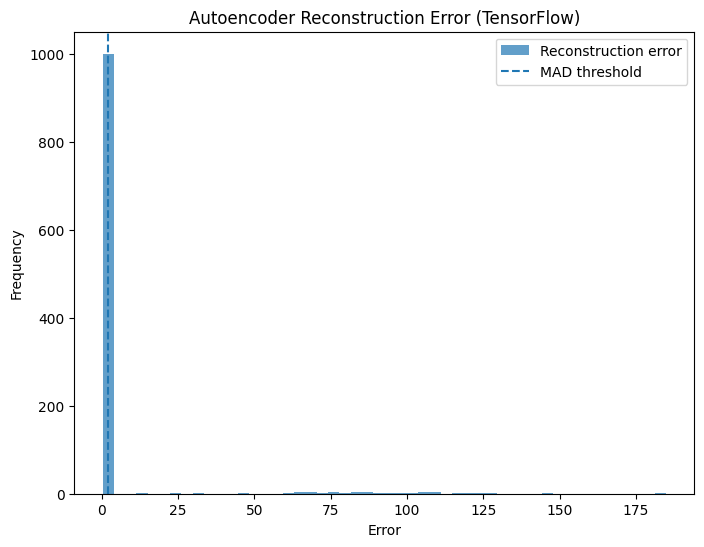

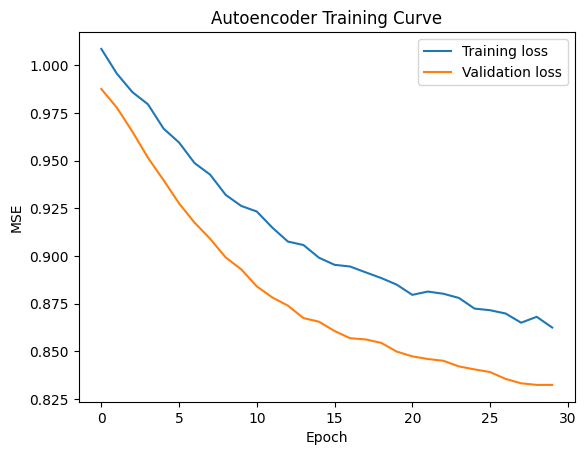

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers

# Set seeds for reproducibility
np.random.seed(42)
tf.random.set_seed(42)

# Generate synthetic data
X = np.random.normal(0, 1, (1000, 20))
n_anomalies = 50
anomalies = np.random.normal(0, 10, (n_anomalies, 20))

X_with_anomalies = np.vstack([X, anomalies])

X_train = X.astype(np.float32)
X_all = X_with_anomalies.astype(np.float32)

input_dim = X_train.shape[1]

inputs = keras.Input(shape=(input_dim,))

# Encoder
x = layers.Dense(32, activation="relu")(inputs)
x = layers.Dropout(0.2)(x)
x = layers.Dense(16, activation="relu")(x)
x = layers.Dropout(0.2)(x)
encoded = layers.Dense(8, activation="relu")(x)

# Decoder
x = layers.Dense(16, activation="relu")(encoded)
x = layers.Dropout(0.2)(x)
x = layers.Dense(32, activation="relu")(x)
decoded = layers.Dense(input_dim)(x)

autoencoder = keras.Model(inputs, decoded)

autoencoder.compile(
    optimizer=keras.optimizers.Adam(learning_rate=1e-3),
    loss="mse"
)

autoencoder.summary()

# Train
history = autoencoder.fit(
    X_train,
    X_train,
    epochs=30,
    batch_size=32,
    shuffle=True,
    validation_split=0.1,
    verbose=1
)

# Reconstruction
X_reconstructed = autoencoder.predict(X_all)

reconstruction_error = np.mean((X_all - X_reconstructed)**2, axis=1)

# We use MAD as a robust threshold
median_error = np.median(reconstruction_error)

mad = np.median(np.abs(reconstruction_error - median_error))

k = 6  # sensitivity parameter

threshold = median_error + k * mad

anomaly_indices = np.where(reconstruction_error > threshold)[0]

print("Median error:", median_error)
print("MAD:", mad)
print("Threshold:", threshold)
print("Detected anomalies:", len(anomaly_indices))

# Plot histogram
plt.figure(figsize=(8,6))

plt.hist(
    reconstruction_error,
    bins=50,
    alpha=0.7,
    label="Reconstruction error"
)

plt.axvline(
    threshold,
    linestyle="--",
    label="MAD threshold"
)

plt.title("Autoencoder Reconstruction Error (TensorFlow)")
plt.xlabel("Error")
plt.ylabel("Frequency")
plt.legend()

plt.show()

# Training curve
plt.figure()

plt.plot(history.history["loss"], label="Training loss")
plt.plot(history.history["val_loss"], label="Validation loss")

plt.xlabel("Epoch")
plt.ylabel("MSE")
plt.title("Autoencoder Training Curve")
plt.legend()

plt.show()

## 10. Time Series Anomaly Detection using Seasonal Decomposition

For time series data, seasonal decomposition can be used to separate trend, seasonal, and residual components. Anomalies are often detected in the residual component where the systematic behavior has been removed.

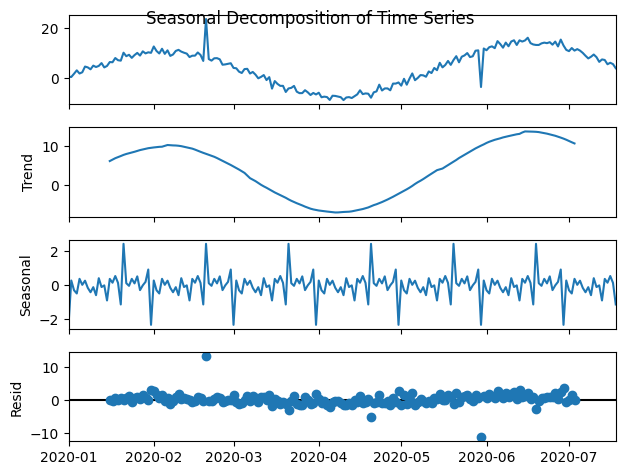

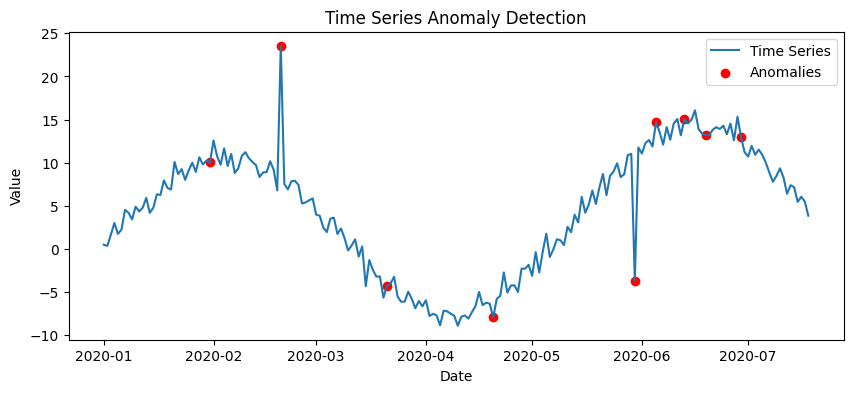

In [10]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from statsmodels.tsa.seasonal import seasonal_decompose

# Create a synthetic time series with a seasonal component
np.random.seed(42)
date_range = pd.date_range(start='2020-01-01', periods=200, freq='D')
seasonal = 10 * np.sin(np.linspace(0, 3 * np.pi, 200))
trend = np.linspace(0, 5, 200)
noise = np.random.normal(0, 1, 200)
ts = seasonal + trend + noise

# Introduce anomalies
ts[50] += 15
ts[150] -= 15
ts_series = pd.Series(ts, index=date_range)

# Decompose the time series
result = seasonal_decompose(ts_series, model='additive', period=30)

# Plot the decomposition
result.plot()
plt.suptitle('Seasonal Decomposition of Time Series')
plt.show()

# Flag anomalies based on the residuals
residual = result.resid.dropna()
threshold = np.percentile(np.abs(residual), 95)
anomalies = residual[np.abs(residual) > threshold]
plt.figure(figsize=(10, 4))
plt.plot(ts_series.index, ts_series, label='Time Series')
plt.scatter(anomalies.index, ts_series[anomalies.index], color='red', label='Anomalies')
plt.title('Time Series Anomaly Detection')
plt.xlabel('Date')
plt.ylabel('Value')
plt.legend()
plt.show()

## References and Further Reading

1. **Chandola, V., Banerjee, A., & Kumar, V. (2009).** Anomaly Detection: A Survey. *ACM Computing Surveys, 41*(3), 15.
2. **Aggarwal, C. C. (2013).** Outlier Analysis. Springer.
3. **Shyu, M.-L., Chen, S.-C., Sarinnapakorn, K., & Chang, L. (2003).** A Novel Anomaly Detection Scheme Based on Principal Component Classifier. *IEEE*.
4. **Ramaswamy, S., Rastogi, R., & Shim, K. (2000).** Efficient Algorithms for Mining Outliers from Large Data Sets. *ACM SIGMOD*.
5. **Sakurada, M., & Yairi, T. (2014).** Anomaly Detection Using Autoencoders with Nonlinear Dimensionality Reduction. *MLSDA Workshop*.

Additional documentation:
- [Scikit-learn Outlier Detection](https://scikit-learn.org/stable/modules/outlier_detection.html)
- [Statsmodels Seasonal Decomposition](https://www.statsmodels.org/stable/generated/statsmodels.tsa.seasonal.seasonal_decompose.html)